# Example 1: Open loop analysis of a coupled mass spring system 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import control as ct 

print("python-control",ct.__version__)
print("NumPy version:", np.__version__)

python-control 0.10.2
NumPy version: 2.3.5


In [6]:
# define the parameters for the system 
m, c, k = 1, 0.1, 2 
# create linear system 
A = np.array([
    [0,0,1,0],
    [0,0,0,1],
    [-2*k/m, k/m, -c/m, 0],
    [k/m, -2*k/m, 0, -c/m]
])
B = np.array([
    [0],
    [0],
    [0],
    [k/m]
])
C = np.array([
    [1,0,0,0],
    [0,1,0,0]
])
D = 0 

sys = ct.ss(A, B, C, D, inputs=['u'], outputs=['$y_1$', '$y_2$'], name='Coupled Spring Mass Damper')
print(sys)

<StateSpace>: Coupled Spring Mass Damper
Inputs (1): ['u']
Outputs (2): ['$y_1$', '$y_2$']
States (4): ['x[0]', 'x[1]', 'x[2]', 'x[3]']

A = [[ 0.   0.   1.   0. ]
     [ 0.   0.   0.   1. ]
     [-4.   2.  -0.1  0. ]
     [ 2.  -4.   0.  -0.1]]

B = [[0.]
     [0.]
     [0.]
     [2.]]

C = [[1. 0. 0. 0.]
     [0. 1. 0. 0.]]

D = [[0.]
     [0.]]


## Initial Response 

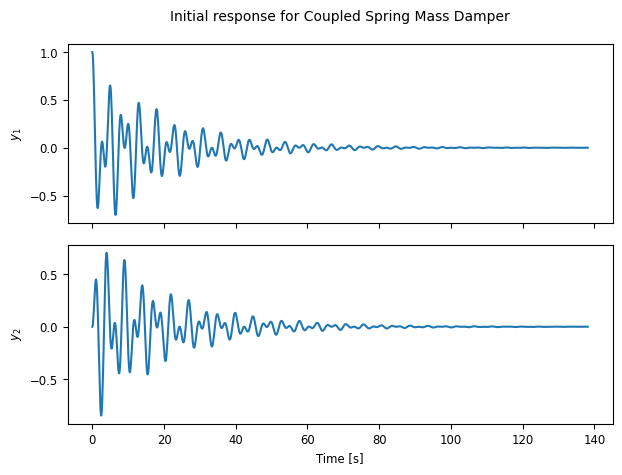

In [7]:
# start from a given initial condition to note the initial response 
response = ct.initial_response(sys, X0=[1,0,0,0])
cplt = response.plot()

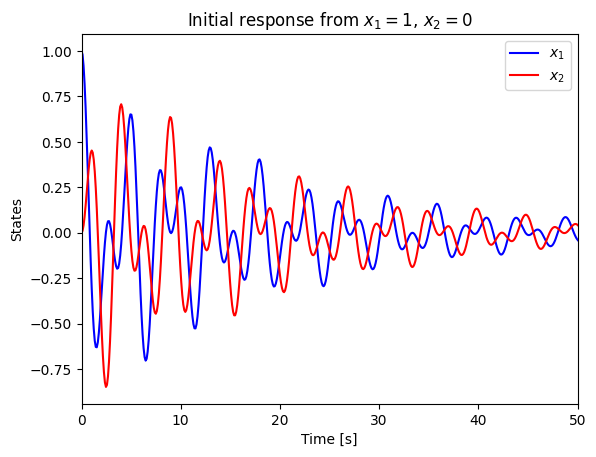

In [19]:
# plot the outputs of the system on the same graph, in different color 
t = response.time 
x = response.states 
plt.plot(t, x[0], 'b', t, x[1], 'r')
plt.legend(['$x_1$', '$x_2$'])
plt.xlim(0, 50)
plt.ylabel('States')
plt.xlabel('Time [s]')
plt.title("Initial response from $x_1=1$, $x_2=0$"); 

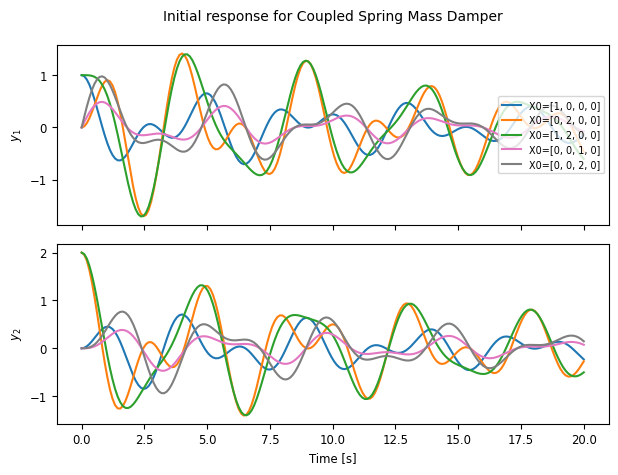

In [20]:
# plots for multiple initial responses 
for X0 in [[1,0,0,0], [0,2,0,0], [1,2,0,0], [0,0,1,0], [0,0,2,0]]: 
    response = ct.initial_response(sys, T=20, X0=X0)
    response.plot(label=f"{X0=}")

## Step response 

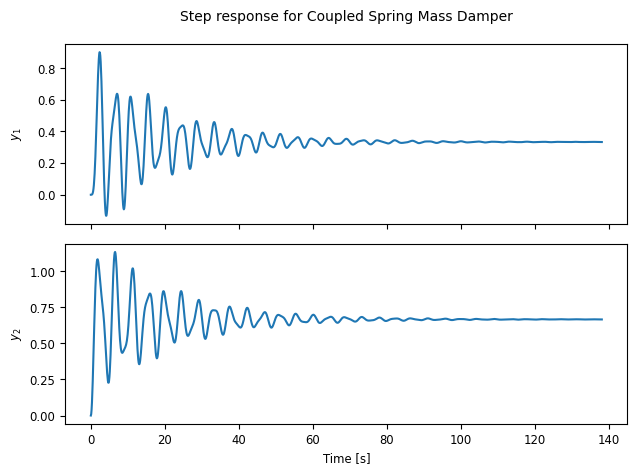

In [ ]:
cplt = ct.step_response(sys).plot() 
# plot inputs as well: cplt = ct.step_response(sys).plot(plot_inputs=True)
# plot inputs on the top of outputs: cplt = ct.step_response(sys).plot(plot_inputs='overlay)

In [22]:
step_info = ct.step_info(sys)
step_info

[[{'RiseTime': 0.615390225299077,
   'SettlingTime': 89.02645259326647,
   'SettlingMin': -0.1327284565536944,
   'SettlingMax': 0.9005994876222034,
   'Overshoot': 170.17984628666105,
   'Undershoot': 39.81853696610832,
   'Peak': 0.9005994876222034,
   'PeakTime': 2.3589958636464616,
   'SteadyStateValue': 0.3333333333333333}],
 [{'RiseTime': 0.6153902252990769,
   'SettlingTime': 73.64169696078955,
   'SettlingMin': 0.22760198207822405,
   'SettlingMax': 1.1338933771021502,
   'Overshoot': 70.08400656532254,
   'Undershoot': 0.0,
   'Peak': 1.1338933771021502,
   'PeakTime': 6.564162403190155,
   'SteadyStateValue': 0.6666666666666666}]]

In [24]:
# Look at the "shape" of the step response
stepresp = ct.step_response(sys)
print(f"{stepresp.time.shape=}")
print(f"{stepresp.inputs.shape=}")
print(f"{stepresp.states.shape=}")
print(f"{stepresp.outputs.shape=}")

stepresp.time.shape=(1348,)
stepresp.inputs.shape=(1, 1, 1348)
stepresp.states.shape=(4, 1, 1348)
stepresp.outputs.shape=(2, 1, 1348)


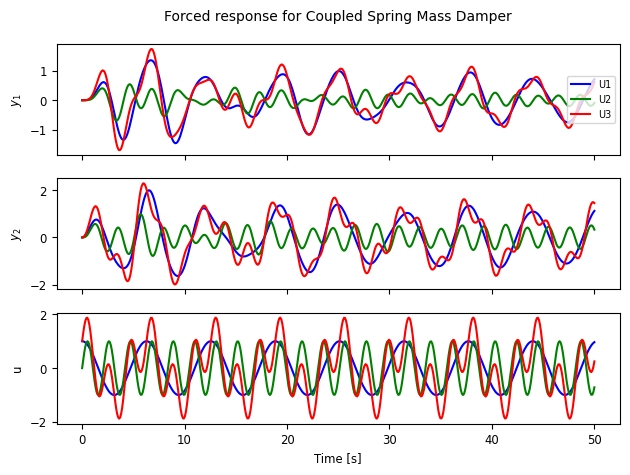

In [25]:
# Forced response 
T = np.linspace(0, 50, 500) 
U1 = np.cos(T)
U2 = np.sin(3*T)

resp1 = ct.forced_response(sys, T, U1)
resp2 = ct.forced_response(sys, T, U2)
resp3 = ct.forced_response(sys, T, U1 + U2)

# Plot the individual responses 
resp1.sysname = 'U1'; resp1.plot(color='b')
resp2.sysname = 'U2'; resp2.plot(color='g')
resp3.sysname = 'U3'; resp3.plot(color='r')

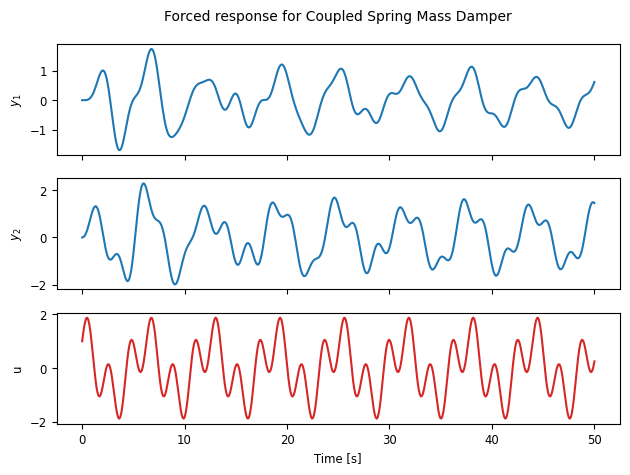

In [26]:
# show that the system response is linear 
cplt = resp3.plot(label="G(U1 + U2)")